In [3]:
%pip install -q kaggle
%echo "installed 'kaggle'"
%pip install -q -U ipywidgets
%echo "installed 'ipywidgets'"
%pip install -q -U jupyter
%echo "installed 'jupyter'"
%pip install -q datasets
%echo "installed 'datasets'"
%pip install -q transformers
%echo "installed 'transformers'"
%pip install -q sentencepiece
%echo "installed 'sentencepiece'"
%pip install -q transformers[torch]
%echo "installed 'transformers'"

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


"installed 'kaggle'"
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


"installed 'ipywidgets'"
Note: you may need to restart the kernel to use updated packages.


...

"installed 'transformers'"
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


"installed 'sentencepiece'"
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


"installed 'transformers'"


In [4]:
RANDOMSEED=1727

In [5]:
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')
# print(iskaggle + "yolo")

In [6]:
creds = '{"username":"longnuub","key":"KGAT_9f6b15aaf6f7637b8497dfb3c56c079e"}'

In [7]:
from pathlib import Path

cred_path = Path('~/.kaggle/kaggle.json').expanduser()
if not cred_path.exists():
    cred_path.parent.mkdir(exist_ok=True)
    cred_path.write_text(creds)
    cred_path.chmod(0o600)

In [8]:
path = Path('us-patent-phrase-to-phrase-matching')

In [9]:
if not iskaggle and not path.exists():
    import zipfile,kaggle
    kaggle.api.competition_download_cli(str(path))
    zipfile.ZipFile(f'{path}.zip').extractall(path)

In [10]:
if iskaggle:
    path = Path('../input/us-patent-phrase-to-phrase-matching')
    ! pip install -q datasets

In [11]:
!dir /o:g /w {path}

 Volume in drive C is Windows
 Volume Serial Number is 6291-898F

 Directory of c:\Users\longnuub\learning-programming-languages\learning-python\kaggle\us-patent-phrase-to-phrase-matching

[..]                    [.]                     test.csv
train.csv               sample_submission.csv   
               3 File(s)      2.143.794 bytes
               2 Dir(s)  126.118.100.992 bytes free


In [12]:
import pandas as pd

In [13]:
df = pd.read_csv(path/'train.csv')

In [14]:
df

,id,anchor,target,context,score
0,37d61fd2272659b1,abatement,abatement of pollution,A47,0.50
1,7b9652b17b68b7a4,abatement,act of abating,A47,0.75
2,36d72442aefd8232,abatement,active catalyst,A47,0.25
3,5296b0c19e1ce60e,abatement,eliminating process,A47,0.50
4,54c1e3b9184cb5b6,abatement,forest region,A47,0.00
...,...,...,...,...,...
36468,8e1386cbefd7f245,wood article,wooden article,B44,1.00
36469,42d9e032d1cd3242,wood article,wooden box,B44,0.50
36470,208654ccb9e14fa3,wood article,wooden handle,B44,0.50
36471,756ec035e694722b,wood article,wooden material,B44,0.75


In [15]:
df.describe(include=["object","str"])

,id,anchor,target,context
count,36473,36473,36473,36473
unique,36473,733,29340,106
top,37d61fd2272659b1,component composite coating,composition,H01
freq,1,152,24,2186


In [16]:
df['input'] = 'TEXT1: ' + df.context + '; TEXT2: ' + df.target + '; ANC1: ' + df.anchor

In [17]:
df.input.head()

0    TEXT1: A47; TEXT2: abatement of pollution; ANC...
1    TEXT1: A47; TEXT2: act of abating; ANC1: abate...
2    TEXT1: A47; TEXT2: active catalyst; ANC1: abat...
3    TEXT1: A47; TEXT2: eliminating process; ANC1: ...
4    TEXT1: A47; TEXT2: forest region; ANC1: abatement
Name: input, dtype: str

In [18]:
from datasets import Dataset,DatasetDict

ds = Dataset.from_pandas(df)
ds

Dataset({
    features: ['id', 'anchor', 'target', 'context', 'score', 'input'],
    num_rows: 36473
})

In [19]:
from transformers import AutoModelForSequenceClassification,AutoTokenizer

model_nm = 'microsoft/deberta-v3-small'
tokz = AutoTokenizer.from_pretrained(model_nm)

In [20]:
print(tokz.tokenize("G'day folks, I'm Jeremy from fast.ai!"),
      "\n\n",
      tokz.tokenize("A platypus is an ornithorhynchus anatinus.")
      )

['▁G', "'", 'day', '▁folks', ',', '▁I', "'", 'm', '▁Jeremy', '▁from', '▁fast', '.', 'ai', '!'] 

 ['▁A', '▁platypus', '▁is', '▁an', '▁or', 'ni', 'tho', 'rhynch', 'us', '▁an', 'at', 'inus', '.']


In [21]:
def tok_func(x): return tokz(x["input"])

In [22]:
tok_ds = ds.map(tok_func, batched=True)

Map:   0%|          | 0/36473 [00:00<?, ? examples/s]

In [23]:
row = tok_ds[0]
row['input'], row['input_ids']

('TEXT1: A47; TEXT2: abatement of pollution; ANC1: abatement',
 [1,
  54453,
  435,
  294,
  336,
  5753,
  346,
  54453,
  445,
  294,
  47284,
  265,
  6435,
  346,
  23702,
  435,
  294,
  47284,
  2])

In [24]:
tokz.vocab['▁of']
# print(tokz.vocab)

265

In [25]:
tok_ds = tok_ds.rename_columns({'score':'labels'})

In [26]:
eval_df = pd.read_csv(path/'test.csv')
eval_df.describe()

,id,anchor,target,context
count,36,36,36,36
unique,36,34,36,29
top,4112d61851461f60,el display,inorganic photoconductor drum,G02
freq,1,2,1,3


In [27]:
def f(x): return -3*x**2 + 2*x + 20

In [28]:
import numpy as np, matplotlib.pyplot as plt

def plot_function(f, min=-2, max=2, color='r'):
    x = np.linspace(min,max, 100)[:,None]
    plt.plot(x, f(x), color)

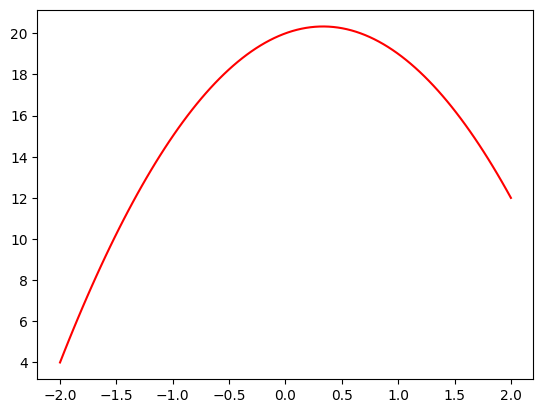

In [29]:
plot_function(f)

In [30]:
from numpy.random import normal,seed,uniform
np.random.seed(RANDOMSEED)

In [31]:
def noise(x, scale): return normal(scale=scale, size=x.shape)
def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)

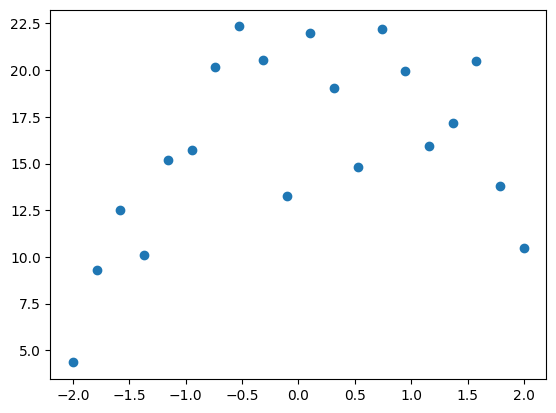

In [32]:
x = np.linspace(-2, 2, num=20)[:,None]
y = add_noise(f(x), 0.2, 1.3)
plt.scatter(x,y)

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def plot_poly(degree):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x, y)
    plt.scatter(x,y)
    plot_function(model.predict)

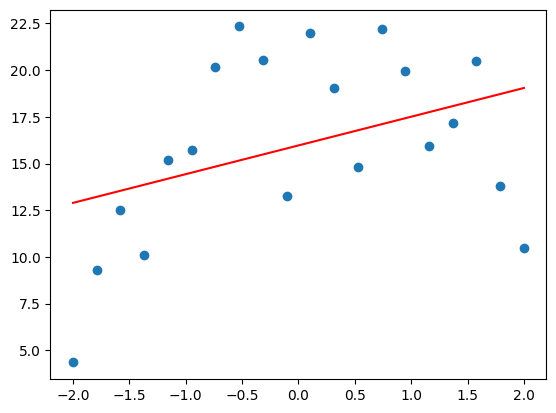

In [34]:
plot_poly(1)

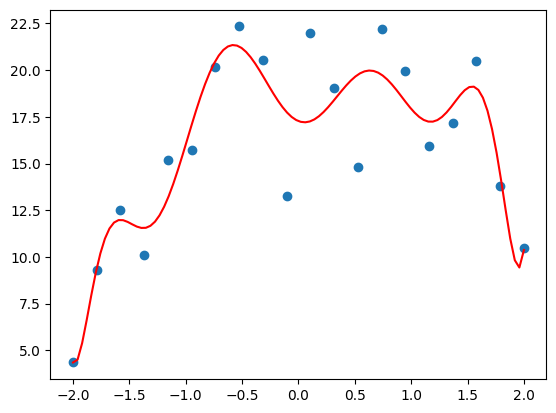

In [35]:
plot_poly(10)

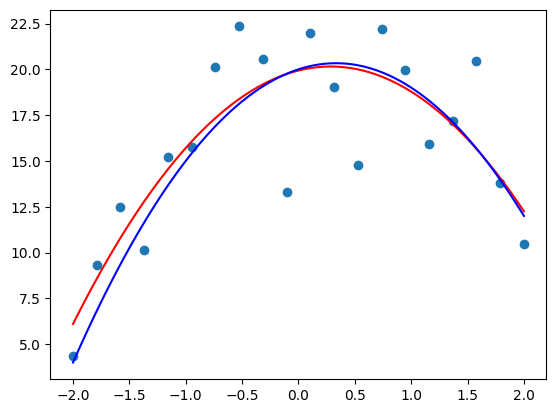

In [36]:
plot_poly(2)
plot_function(f,color="blue")

In [37]:
dds = tok_ds.train_test_split(0.25, seed=RANDOMSEED)
dds

DatasetDict({
    train: Dataset({
        features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 27354
    })
    test: Dataset({
        features: ['id', 'anchor', 'target', 'context', 'labels', 'input', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9119
    })
})

In [38]:
eval_df['input'] = 'TEXT1: ' + eval_df.context + '; TEXT2: ' + eval_df.target + '; ANC1: ' + eval_df.anchor
eval_ds = Dataset.from_pandas(eval_df).map(tok_func, batched=True)

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

In [39]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)
housing = housing['data'].join(housing['target']).sample(1000, random_state=52)
housing.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
7506,3.0550,37.0,5.152778,1.048611,729.0,5.062500,33.92,-118.28,1.054
4720,3.0862,35.0,4.697897,1.055449,1159.0,2.216061,34.05,-118.37,3.453
12888,2.5556,24.0,4.864905,1.129222,1631.0,2.395007,38.66,-121.35,1.057
13344,3.0057,32.0,4.212687,0.936567,1378.0,5.141791,34.05,-117.64,0.969
7173,1.9083,42.0,3.888554,1.039157,1535.0,4.623494,34.05,-118.19,1.192


In [40]:
np.set_printoptions(precision=2, suppress=True)
np.corrcoef(housing, rowvar=False)

array([[ 1.  , -0.12,  0.43, -0.08,  0.01, -0.07, -0.12,  0.04,  0.68],
       [-0.12,  1.  , -0.17, -0.06, -0.31,  0.  ,  0.03, -0.13,  0.12],
       [ 0.43, -0.17,  1.  ,  0.76, -0.09, -0.07,  0.12, -0.03,  0.21],
       [-0.08, -0.06,  0.76,  1.  , -0.08, -0.07,  0.09,  0.  , -0.04],
       [ 0.01, -0.31, -0.09, -0.08,  1.  ,  0.16, -0.15,  0.13,  0.  ],
       [-0.07,  0.  , -0.07, -0.07,  0.16,  1.  , -0.16,  0.17, -0.27],
       [-0.12,  0.03,  0.12,  0.09, -0.15, -0.16,  1.  , -0.93, -0.16],
       [ 0.04, -0.13, -0.03,  0.  ,  0.13,  0.17, -0.93,  1.  , -0.03],
       [ 0.68,  0.12,  0.21, -0.04,  0.  , -0.27, -0.16, -0.03,  1.  ]])

In [41]:
np.corrcoef(housing.MedInc, housing.MedHouseVal)

array([[1.  , 0.68],
       [0.68, 1.  ]])

In [42]:
def corr(x,y): return np.corrcoef(x,y)[0][1]
corr(housing.MedInc, housing.MedHouseVal)

np.float64(0.6760250732906004)

In [43]:
def show_corr(df, a, b):
	x,y = df[a],df[b]
	plt.scatter(x,y, alpha=0.5, s=4)
	plt.title(f'{a} vs {b}; r: {corr(x, y):.2f}')

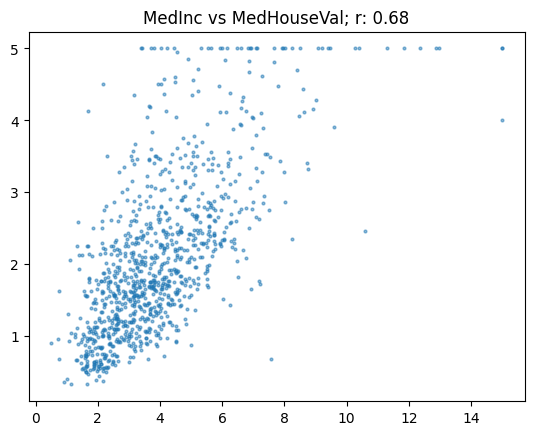

In [44]:
show_corr(housing, 'MedInc', 'MedHouseVal')

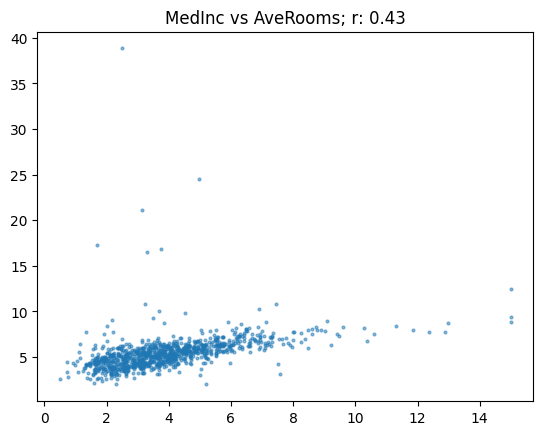

In [45]:
show_corr(housing, 'MedInc', 'AveRooms')

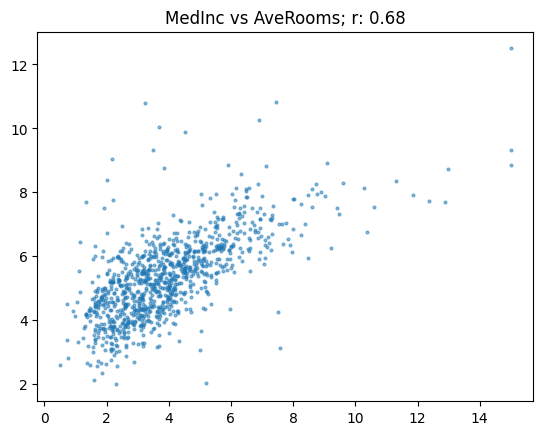

In [46]:
subset = housing[housing.AveRooms<15]
show_corr(subset, 'MedInc', 'AveRooms')

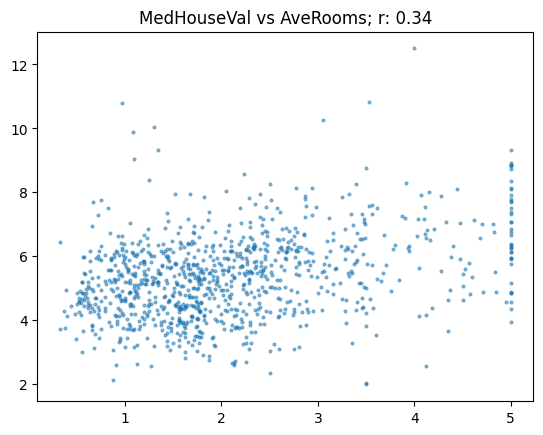

In [47]:
show_corr(subset, 'MedHouseVal', 'AveRooms')

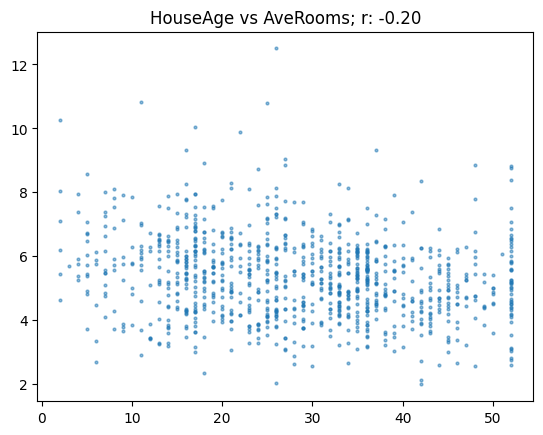

In [48]:
show_corr(subset, 'HouseAge', 'AveRooms')

In [49]:
def corr_d(eval_pred): return {'pearson': corr(*eval_pred)}

In [50]:
from transformers import TrainingArguments,Trainer

In [72]:
bs = 128
epochs = 4
lr = 8e-5

In [73]:
args = TrainingArguments(
	'outputs',
	learning_rate=lr,
	warmup_ratio=0.1, 
	lr_scheduler_type='cosine',
	# fp16=True,
	bf16=True,
	eval_strategy="epoch", 
	per_device_train_batch_size=bs,
	per_device_eval_batch_size=bs*2,
	num_train_epochs=epochs,
	weight_decay=0.01,
	report_to='none'
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [74]:
model = AutoModelForSequenceClassification.from_pretrained(model_nm, num_labels=1)
trainer = Trainer(model, args, train_dataset=dds['train'], eval_dataset=dds['test'],
                  processing_class=tokz, compute_metrics=corr_d)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifie

In [75]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Pearson
1,No log,nan,nan


KeyboardInterrupt: 

In [60]:
preds = trainer.predict(eval_ds).predictions.astype(float)
preds[:5]

array([[nan],
       [nan],
       [nan],
       [nan],
       [nan]])

In [59]:
preds = np.clip(preds, 0, 1)
preds[:5]

array([[nan],
       [nan],
       [nan],
       [nan],
       [nan]])

In [57]:
sub_df=pd.DataFrame({
  "id":eval_ds["id"],
  "score":preds
})

ValueError: Per-column arrays must each be 1-dimensional